# XIII. web_traffic.csv — Lưu lượng truy cập web


In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import math


# Cấu hình hiển thị
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
warnings.filterwarnings('ignore')
sns.set(style="whitegrid")

# Định nghĩa đường dẫn dữ liệu (Sửa theo folder của nhóm)
CURRENT_DIR = os.getcwd()
ROOT_DIR = os.path.dirname(CURRENT_DIR)
ROOT_DIR = os.path.dirname(ROOT_DIR)
DATA_RAW_PATH = os.path.join(ROOT_DIR, "data", 'raw')
PROCESSED_PATH = os.path.join(ROOT_DIR, 'data', 'processed')
print(f"Data path: {DATA_RAW_PATH}")

IMAGES_DIR = os.path.join(ROOT_DIR, 'outputs', 'images')
if not os.path.exists(IMAGES_DIR):
    os.makedirs(IMAGES_DIR)

def load_and_clean_data():
    # 1. Load Master Data
    customers = pd.read_csv(os.path.join(DATA_RAW_PATH, 'customers.csv'))
    geography = pd.read_csv(os.path.join(DATA_RAW_PATH, 'geography.csv'))
    inventory = pd.read_csv(os.path.join(DATA_RAW_PATH, 'inventory.csv'))
    products = pd.read_csv(os.path.join(DATA_RAW_PATH, 'products.csv'))
    promotions = pd.read_csv(os.path.join(DATA_RAW_PATH, 'promotions.csv'))

    # 2. Load Transactional / Supporting Data
    orders = pd.read_csv(os.path.join(DATA_RAW_PATH, 'orders.csv'))
    order_items = pd.read_csv(os.path.join(DATA_RAW_PATH, 'order_items.csv'))
    payments = pd.read_csv(os.path.join(DATA_RAW_PATH, 'payments.csv'))
    returns = pd.read_csv(os.path.join(DATA_RAW_PATH, 'returns.csv'))
    reviews = pd.read_csv(os.path.join(DATA_RAW_PATH, 'reviews.csv'))
    sales = pd.read_csv(os.path.join(DATA_RAW_PATH, 'sales.csv'))
    sample_submission = pd.read_csv(os.path.join(DATA_RAW_PATH, 'sample_submission.csv'))
    shipments = pd.read_csv(os.path.join(DATA_RAW_PATH, 'shipments.csv'))
    web_traffic = pd.read_csv(os.path.join(DATA_RAW_PATH, 'web_traffic.csv'))

    # 3. Ép kiểu datetime cho các cột ngày tháng
    dataframes = {
        'customers': customers,
        'inventory': inventory,
        'orders': orders,
        'promotions': promotions,
        'returns': returns,
        'reviews': reviews,
        'sales': sales,
        'sample_submission': sample_submission,
        'shipments': shipments,
        'web_traffic': web_traffic,
    }

    date_cols = {
        'customers': ['signup_date'],
        'inventory': ['snapshot_date'],
        'orders': ['order_date'],
        'promotions': ['start_date', 'end_date'],
        'returns': ['return_date'],
        'reviews': ['review_date'],
        'sales': ['Date'],
        'sample_submission': ['Date'],
        'shipments': ['ship_date', 'delivery_date'],
        'web_traffic': ['date'],
    }

    for df_name, cols in date_cols.items():
        for col in cols:
            if col in dataframes[df_name].columns:
                dataframes[df_name][col] = pd.to_datetime(dataframes[df_name][col], errors='coerce')

    return (
        customers,
        geography,
        inventory,
        orders,
        order_items,
        payments,
        products,
        promotions,
        returns,
        reviews,
        sales,
        sample_submission,
        shipments,
        web_traffic,
    )

(
    customers_df,
    geography_df,
    inventory_df,
    orders_df,
    order_items_df,
    payments_df,
    products_df,
    promotions_df,
    returns_df,
    reviews_df,
    sales_df,
    sample_submission_df,
    shipments_df,
    web_traffic_df,
) = load_and_clean_data()

num_cols = ['sessions', 'unique_visitors', 'page_views', 'bounce_rate', 'avg_session_duration_sec']
for col in num_cols:
    web_traffic_df[col] = pd.to_numeric(web_traffic_df[col], errors='coerce')

web_traffic_df['bounce_rate_pct'] = web_traffic_df['bounce_rate'] * 100
web_traffic_df['engagement_per_session'] = web_traffic_df['page_views'] / web_traffic_df['sessions']
web_traffic_df['visitor_session_ratio'] = web_traffic_df['unique_visitors'] / web_traffic_df['sessions']

web_traffic_df['year'] = web_traffic_df['date'].dt.year
web_traffic_df['month'] = web_traffic_df['date'].dt.month
web_traffic_df['year_month'] = web_traffic_df['date'].dt.to_period('M')

weekday_map = {
    'Monday': 'Thứ 2',
    'Tuesday': 'Thứ 3',
    'Wednesday': 'Thứ 4',
    'Thursday': 'Thứ 5',
    'Friday': 'Thứ 6',
    'Saturday': 'Thứ 7',
    'Sunday': 'Chủ nhật'
}
web_traffic_df['day_of_week'] = web_traffic_df['date'].dt.day_name().map(weekday_map)

month_name_map = {
    1: 'Tháng 1', 2: 'Tháng 2', 3: 'Tháng 3', 4: 'Tháng 4', 5: 'Tháng 5', 6: 'Tháng 6',
    7: 'Tháng 7', 8: 'Tháng 8', 9: 'Tháng 9', 10: 'Tháng 10', 11: 'Tháng 11', 12: 'Tháng 12'
}
web_traffic_df['month_name'] = web_traffic_df['month'].map(month_name_map)

web_traffic_df['bounce_band'] = pd.cut(
    web_traffic_df['bounce_rate_pct'],
    bins=[0, 0.40, 0.45, 0.50, 0.55, 1],
    labels=['<=0.40%', '0.40-0.45%', '0.45-0.50%', '0.50-0.55%', '>0.55%'],
    include_lowest=True
)

Data path: /Users/tawannt/Study/Github/DATATHON-2026-VinUni/data/raw


## 1. Tổng quan


In [50]:
web_traffic_df.head(10)

,date,sessions,unique_visitors,page_views,bounce_rate,avg_session_duration_sec,traffic_source,bounce_rate_pct,engagement_per_session,visitor_session_ratio,year,month,year_month,day_of_week,month_name,bounce_band
0,2013-01-01,9760,7253,39093,0.01,102.90,organic_search,0.51,4.01,0.74,2013,1,2013-01,Thứ 3,Tháng 1,0.50-0.55%
1,2013-01-02,10456,8151,47611,0.00,120.50,organic_search,0.41,4.55,0.78,2013,1,2013-01,Thứ 4,Tháng 1,0.40-0.45%
2,2013-01-03,10076,7458,36963,0.00,263.60,direct,0.40,3.67,0.74,2013,1,2013-01,Thứ 5,Tháng 1,0.40-0.45%
3,2013-01-04,9973,8063,53078,0.01,151.80,direct,0.56,5.32,0.81,2013,1,2013-01,Thứ 6,Tháng 1,>0.55%
4,2013-01-05,10223,7882,36790,0.01,168.60,referral,0.53,3.60,0.77,2013,1,2013-01,Thứ 7,Tháng 1,0.50-0.55%
5,2013-01-06,9545,6992,47160,0.00,263.60,social_media,0.44,4.94,0.73,2013,1,2013-01,Chủ nhật,Tháng 1,0.40-0.45%
6,2013-01-07,10203,7354,32749,0.00,252.10,organic_search,0.44,3.21,0.72,2013,1,2013-01,Thứ 2,Tháng 1,0.40-0.45%
7,2013-01-08,9456,7459,31482,0.00,192.40,paid_search,0.44,3.33,0.79,2013,1,2013-01,Thứ 3,Tháng 1,0.40-0.45%
8,2013-01-09,9162,7108,46717,0.00,312.80,organic_search,0.41,5.10,0.78,2013,1,2013-01,Thứ 4,Tháng 1,0.40-0.45%
9,2013-01-10,9887,7878,38472,0.01,285.40,organic_search,0.54,3.89,0.80,2013,1,2013-01,Thứ 5,Tháng 1,0.50-0.55%


In [51]:
web_traffic_df.shape


(3652, 16)

In [52]:
web_traffic_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3652 entries, 0 to 3651
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   date                      3652 non-null   datetime64[us]
 1   sessions                  3652 non-null   int64         
 2   unique_visitors           3652 non-null   int64         
 3   page_views                3652 non-null   int64         
 4   bounce_rate               3652 non-null   float64       
 5   avg_session_duration_sec  3652 non-null   float64       
 6   traffic_source            3652 non-null   str           
 7   bounce_rate_pct           3652 non-null   float64       
 8   engagement_per_session    3652 non-null   float64       
 9   visitor_session_ratio     3652 non-null   float64       
 10  year                      3652 non-null   int32         
 11  month                     3652 non-null   int32         
 12  year_month                3652 

In [53]:
web_traffic_df.columns

Index(['date', 'sessions', 'unique_visitors', 'page_views', 'bounce_rate',
       'avg_session_duration_sec', 'traffic_source', 'bounce_rate_pct',
       'engagement_per_session', 'visitor_session_ratio', 'year', 'month',
       'year_month', 'day_of_week', 'month_name', 'bounce_band'],
      dtype='str')

In [54]:
overview_df = pd.DataFrame({
    'missing_count': web_traffic_df.isna().sum(),
    'missing_rate_%': (web_traffic_df.isna().mean() * 100).round(2),
    'n_unique': web_traffic_df.nunique(dropna=False)
})
overview_df

,missing_count,missing_rate_%,n_unique
date,0,0.00,3652
sessions,0,0.00,3447
unique_visitors,0,0.00,3382
page_views,0,0.00,3620
bounce_rate,0,0.00,261
avg_session_duration_sec,0,0.00,1771
traffic_source,0,0.00,6
bounce_rate_pct,0,0.00,261
engagement_per_session,0,0.00,3652
visitor_session_ratio,0,0.00,3649


In [55]:
summary_df = pd.DataFrame({
    'date_min': [web_traffic_df['date'].min()],
    'date_max': [web_traffic_df['date'].max()],
    'unique_dates': [web_traffic_df['date'].nunique()],
    'unique_traffic_sources': [web_traffic_df['traffic_source'].nunique()],
    'avg_sessions': [round(web_traffic_df['sessions'].mean(), 2)],
    'avg_page_views': [round(web_traffic_df['page_views'].mean(), 2)]
})
summary_df

,date_min,date_max,unique_dates,unique_traffic_sources,avg_sessions,avg_page_views
0,2013-01-01,2022-12-31,3652,6,25041.77,108615.22


**Nhận xét:**

- **Quan sát:**
  - Dữ liệu `web_traffic` đang bao phủ giai đoạn từ `2013-01-01` đến `2022-12-31`, gồm `3,652` bản ghi và cũng đúng `3,652` ngày khác nhau. Điều này cho thấy trong file hiện tại, mỗi ngày chỉ xuất hiện một dòng dữ liệu tổng hợp.
  - Biến `traffic_source` có `6` giá trị khác nhau, nhưng với grain thực tế của file hiện tại, mỗi ngày chỉ gắn với một nguồn traffic, thay vì đồng thời có nhiều nguồn trong cùng một ngày.
  - Mức traffic trung bình toàn bộ tập dữ liệu đạt khoảng `25,041.77 sessions/ngày` và `108,615.22 page_views/ngày`, cho thấy đây là tập dữ liệu vận hành ở quy mô khá lớn và phù hợp để phân tích xu hướng dài hạn.

- **Insights:**
  - Khi đọc notebook này, cần bám theo grain thực tế của file hơn là mô tả lý thuyết trong `DATA.md`: đây đang là daily aggregate ở cấp file, không phải bảng chi tiết `date x traffic_source` theo đúng nghĩa đầy đủ.
  - Vì vậy, các so sánh theo `traffic_source` trong notebook nên được hiểu là so sánh giữa các ngày được gắn nhãn nguồn khác nhau, chứ chưa phản ánh cơ cấu đóng góp đồng thời của nhiều nguồn trong cùng một ngày.

- **Gợi ý hành động:**
  - Giữ nguyên giả định grain này cho toàn bộ phần EDA để tránh diễn giải sai business meaning của biểu đồ.
  - Nếu team cần phân tích attribution theo nguồn truy cập sâu hơn, nên bổ sung thêm dữ liệu traffic ở cấp `date x source` hoặc cấp campaign/session để đo đúng market mix và hiệu quả kênh.

## 1.1. Phân tích đơn biến


### 1.1.1. Biến số (Numerous)


#### a. Nhóm lưu lượng truy cập


Đã lưu biểu đồ kết hợp tại: /Users/tawannt/Study/Github/DATATHON-2026-VinUni/outputs/images/web_traffic_volume_distribution_boxplot.png


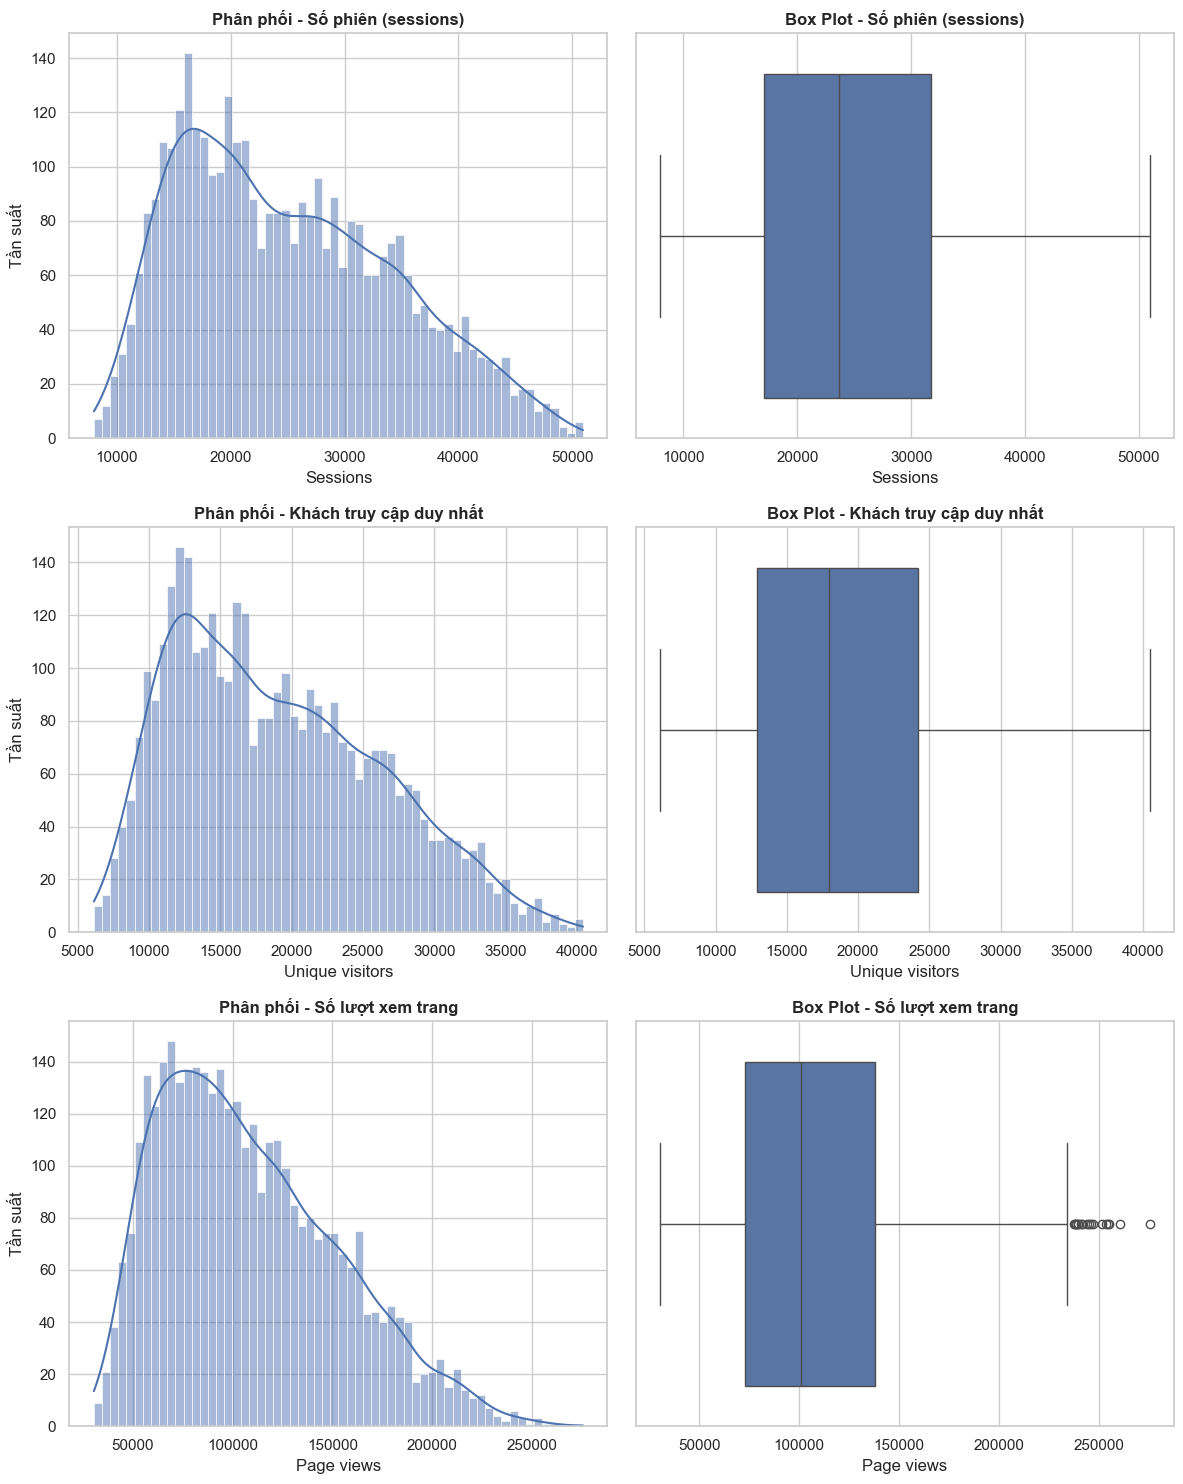

In [56]:
col_config_traffic = {
    'sessions': {'title': 'Số phiên (sessions)', 'xlabel': 'Sessions', 'hist_kwargs': {'bins': 60}},
    'unique_visitors': {'title': 'Khách truy cập duy nhất', 'xlabel': 'Unique visitors', 'hist_kwargs': {'bins': 60}},
    'page_views': {'title': 'Số lượt xem trang', 'xlabel': 'Page views', 'hist_kwargs': {'bins': 60}}
}

traffic_cols = ['sessions', 'unique_visitors', 'page_views']

def plot_distribution_boxplot(df, con_cols_names, config_dict, save_path=None):
    n = len(con_cols_names)
    plt.figure(figsize=(12, 5 * n))

    for i, col_name in enumerate(con_cols_names):
        cfg = config_dict.get(col_name, {'title': col_name, 'xlabel': 'Giá trị', 'hist_kwargs': {}})
        values = df[col_name].dropna()

        ax1 = plt.subplot(n, 2, 2 * i + 1)
        sns.histplot(values, kde=True, ax=ax1, **cfg.get('hist_kwargs', {}))
        ax1.set_title(f"Phân phối - {cfg['title']}", fontweight='bold')
        ax1.set_xlabel(cfg['xlabel'])
        ax1.set_ylabel('Tần suất')

        ax2 = plt.subplot(n, 2, 2 * i + 2)
        sns.boxplot(x=values, ax=ax2)
        ax2.set_title(f"Box Plot - {cfg['title']}", fontweight='bold')
        ax2.set_xlabel(cfg['xlabel'])

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
        print(f'Đã lưu biểu đồ kết hợp tại: {save_path}')

    plt.show()

plot_distribution_boxplot(
    web_traffic_df,
    traffic_cols,
    col_config_traffic,
    save_path=os.path.join(IMAGES_DIR, 'web_traffic_volume_distribution_boxplot.png')
)

In [57]:
web_traffic_df[traffic_cols].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99])

,sessions,unique_visitors,page_views
count,3652.00,3652.00,3652.00
mean,25041.77,19031.40,108615.22
std,9422.61,7237.95,44472.06
min,7973.00,6136.00,30451.00
1%,10038.06,7516.77,39353.04
5%,12332.90,9327.85,50073.40
25%,17099.25,12915.00,72982.00
50%,23633.50,17924.00,101010.50
75%,31782.75,24191.75,138086.00
90%,38764.10,29407.00,172393.50


**Nhận xét:**

- **Quan sát:**
  - Ba biến lưu lượng chính gồm `sessions`, `unique_visitors` và `page_views` đều có phân phối lệch phải. Median của `sessions` khoảng `23.6k`, trong khi mean khoảng `25.0k`; tương tự, median của `page_views` khoảng `101.0k`, thấp hơn mean `108.6k`.
  - Độ phân tán của traffic khá lớn: `sessions` dao động từ khoảng `8.0k` đến `50.9k`, còn `page_views` từ khoảng `30.5k` đến `275.6k`. Điều này cho thấy cường độ truy cập giữa các ngày biến động mạnh.
  - `unique_visitors` bám rất sát theo `sessions`, phản ánh số lượng phiên và số người dùng duy nhất cùng tăng giảm rõ rệt theo từng ngày vận hành.

- **Insights:**
  - Website có tính mùa vụ hoặc bị chi phối đáng kể bởi lịch chiến dịch, vì phân phối traffic không hội tụ chặt quanh một mức cố định mà trải khá rộng.
  - Những ngày volume cao nhiều khả năng đến từ các đợt đẩy truyền thông, khuyến mãi hoặc các giai đoạn cao điểm mua sắm; trong khi đó phần đáy của phân phối cho thấy vẫn tồn tại những ngày traffic yếu đáng kể.

- **Gợi ý hành động:**
  - Tách riêng nhóm ngày volume cao nhất và thấp nhất để đối chiếu với lịch campaign, ngày lễ và hoạt động marketing nhằm xác định động lực tăng trưởng traffic.
  - Khi xây dashboard vận hành, nên theo dõi thêm percentile hoặc rolling average thay vì chỉ nhìn mean, vì mean đang bị kéo lên bởi các ngày traffic cao.

#### b. Nhóm chất lượng phiên truy cập


Đã lưu biểu đồ kết hợp tại: /Users/tawannt/Study/Github/DATATHON-2026-VinUni/outputs/images/web_traffic_quality_distribution_boxplot.png


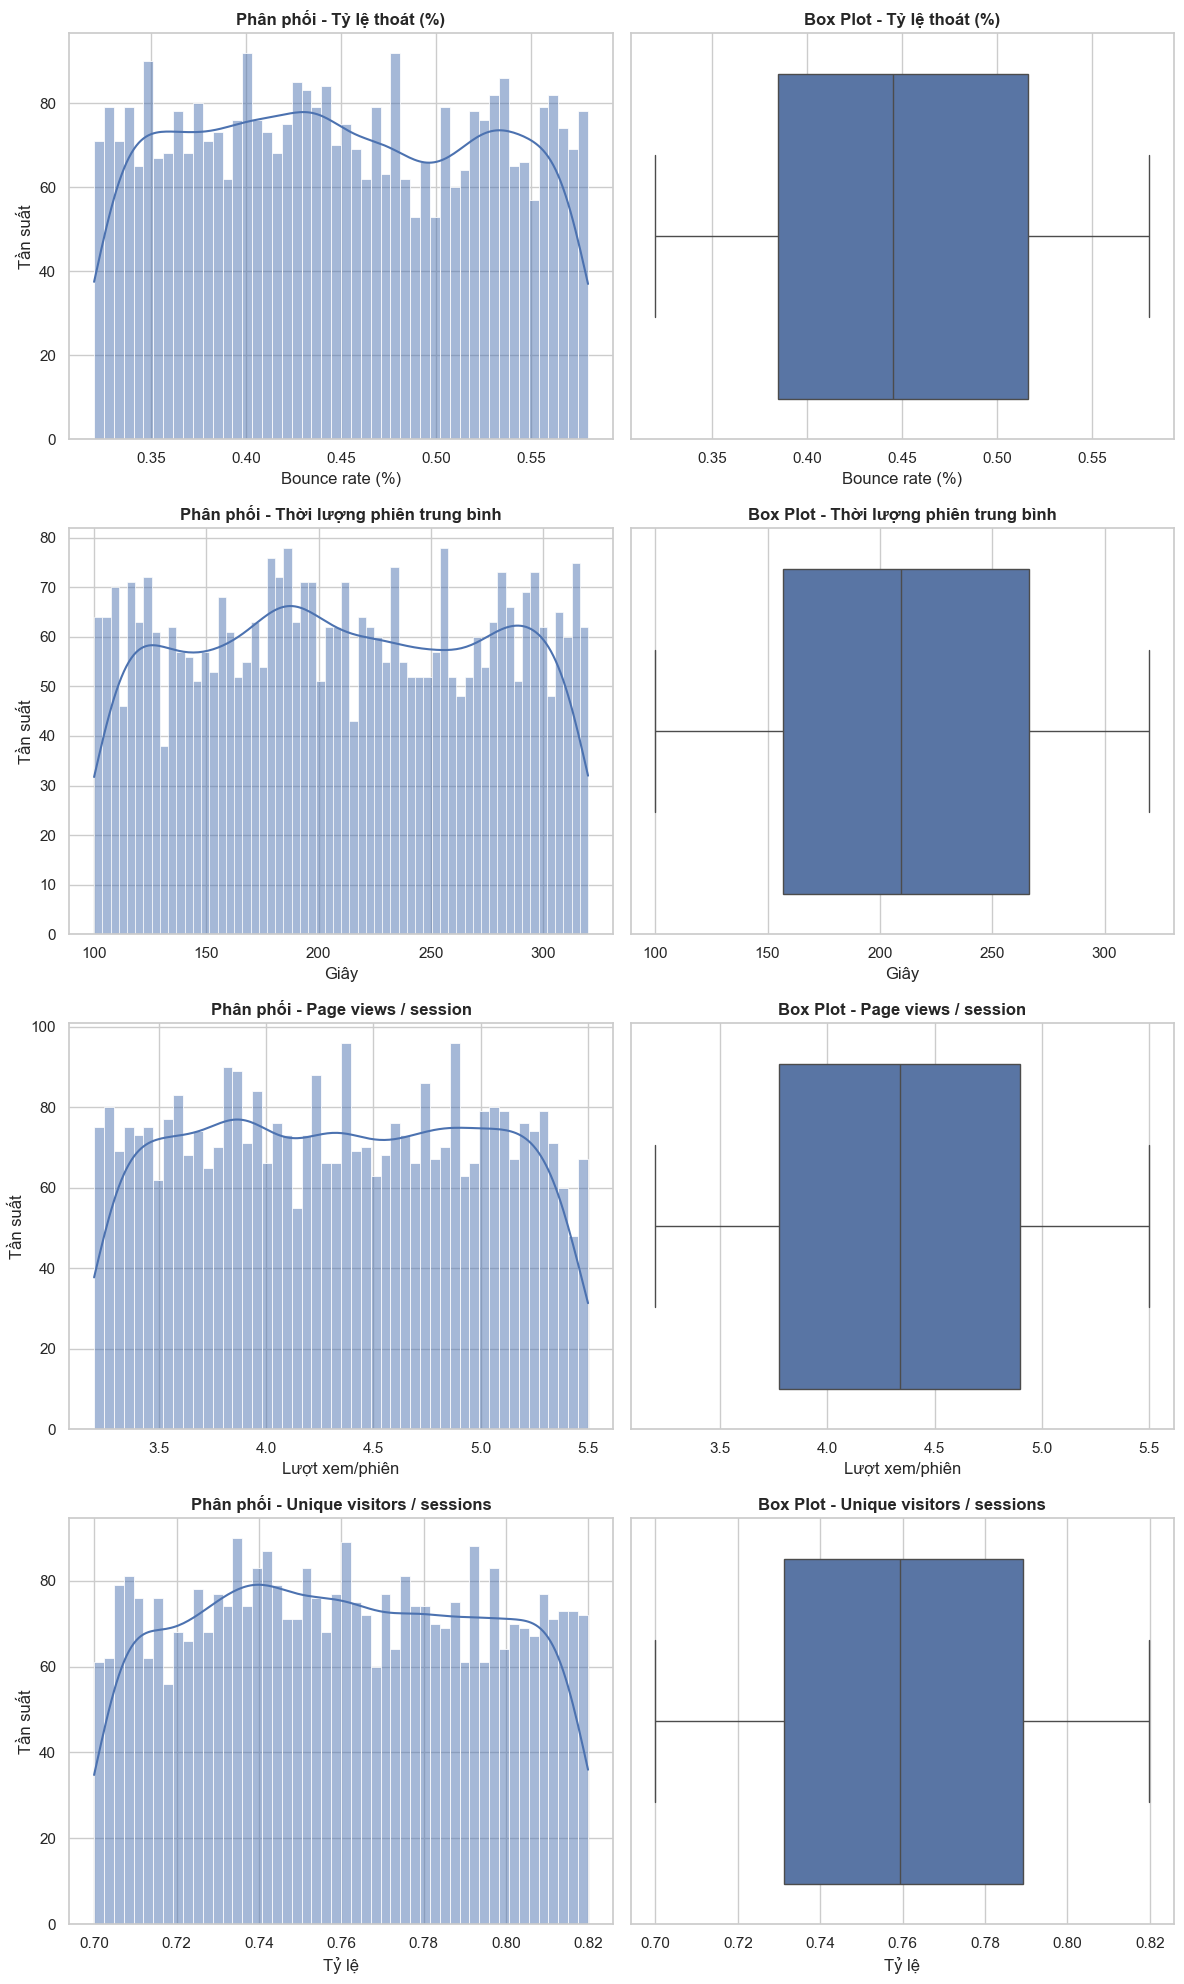

In [58]:
col_config_quality = {
    'bounce_rate_pct': {'title': 'Tỷ lệ thoát (%)', 'xlabel': 'Bounce rate (%)', 'hist_kwargs': {'bins': 50}},
    'avg_session_duration_sec': {'title': 'Thời lượng phiên trung bình', 'xlabel': 'Giây', 'hist_kwargs': {'bins': 60}},
    'engagement_per_session': {'title': 'Page views / session', 'xlabel': 'Lượt xem/phiên', 'hist_kwargs': {'bins': 50}},
    'visitor_session_ratio': {'title': 'Unique visitors / sessions', 'xlabel': 'Tỷ lệ', 'hist_kwargs': {'bins': 50}}
}

quality_cols = ['bounce_rate_pct', 'avg_session_duration_sec', 'engagement_per_session', 'visitor_session_ratio']
plot_distribution_boxplot(
    web_traffic_df,
    quality_cols,
    col_config_quality,
    save_path=os.path.join(IMAGES_DIR, 'web_traffic_quality_distribution_boxplot.png')
)

In [59]:
web_traffic_df[quality_cols].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99])

,bounce_rate_pct,avg_session_duration_sec,engagement_per_session,visitor_session_ratio
count,3652.00,3652.00,3652.00,3652.00
mean,0.45,210.28,4.34,0.76
std,0.08,63.77,0.66,0.03
min,0.32,100.10,3.20,0.70
1%,0.32,102.00,3.22,0.70
5%,0.33,109.90,3.31,0.71
25%,0.38,156.70,3.78,0.73
50%,0.45,209.20,4.34,0.76
75%,0.52,266.20,4.90,0.79
90%,0.56,298.30,5.25,0.81


In [60]:
q1 = web_traffic_df['bounce_rate_pct'].quantile(0.25)
q3 = web_traffic_df['bounce_rate_pct'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outlier_mask = (web_traffic_df['bounce_rate_pct'] < lower_bound) | (web_traffic_df['bounce_rate_pct'] > upper_bound)
outlier_count = int(outlier_mask.sum())
outlier_rate = outlier_count / len(web_traffic_df) * 100

print(f'Q1: {q1:,.4f}')
print(f'Q3: {q3:,.4f}')
print(f'IQR: {iqr:,.4f}')
print(f'Lower bound: {lower_bound:,.4f}')
print(f'Upper bound: {upper_bound:,.4f}')
print(f'Số lượng outlier (IQR): {outlier_count:,}')
print(f'Tỷ lệ outlier (IQR): {outlier_rate:.2f}%')

Q1: 0.3848
Q3: 0.5160
IQR: 0.1312
Lower bound: 0.1879
Upper bound: 0.7129
Số lượng outlier (IQR): 0
Tỷ lệ outlier (IQR): 0.00%


**Nhận xét:**

- **Quan sát:**
  - `bounce_rate_pct` phân bố tương đối ổn định, với Q1 khoảng `0.3848`, Q3 khoảng `0.5160` và không ghi nhận outlier theo quy tắc IQR. Đây là tín hiệu cho thấy tỷ lệ thoát giữa các ngày không có các cú sốc bất thường quá lớn.
  - `avg_session_duration_sec` tập trung quanh vùng hơn `200 giây`, trong khi `engagement_per_session` xoay quanh mức hơn `4 page_views/session`. Hai biến này cho thấy chất lượng phiên nhìn chung khá đều giữa các ngày.
  - `visitor_session_ratio` ở mức tương đối cao và phân bố không quá phân mảnh, hàm ý số `unique_visitors` và `sessions` đang có quan hệ khá ổn định trong phần lớn thời gian quan sát.

- **Insights:**
  - So với nhóm biến volume, nhóm biến chất lượng phiên có độ ổn định tốt hơn. Điều này gợi ý hệ thống traffic của website tăng giảm khá mạnh về lượng, nhưng trải nghiệm truy cập chưa bị kéo lệch quá nhiều theo từng ngày.
  - Việc `bounce_rate_pct` không xuất hiện outlier IQR là một tín hiệu tích cực: nếu có vấn đề chất lượng traffic, nó nhiều khả năng đến từ dịch chuyển mức nền theo giai đoạn hơn là một vài ngày cực đoan đơn lẻ.

- **Gợi ý hành động:**
  - Thiết lập ngưỡng cảnh báo vận hành cho `bounce_rate_pct`, `avg_session_duration_sec` và `engagement_per_session` theo rolling window để phát hiện sớm khi chất lượng traffic xuống dưới mức nền bình thường.
  - Khi phân tích sâu các ngày volume đột biến, nên kiểm tra song song các chỉ số chất lượng này để xác định traffic tăng là tăng "tốt" hay chỉ là traffic số lượng.

### 1.1.2. Biến phân loại (Categorical)


Đã lưu biểu đồ categorical tại: /Users/tawannt/Study/Github/DATATHON-2026-VinUni/outputs/images/web_traffic_categorical_distribution.png


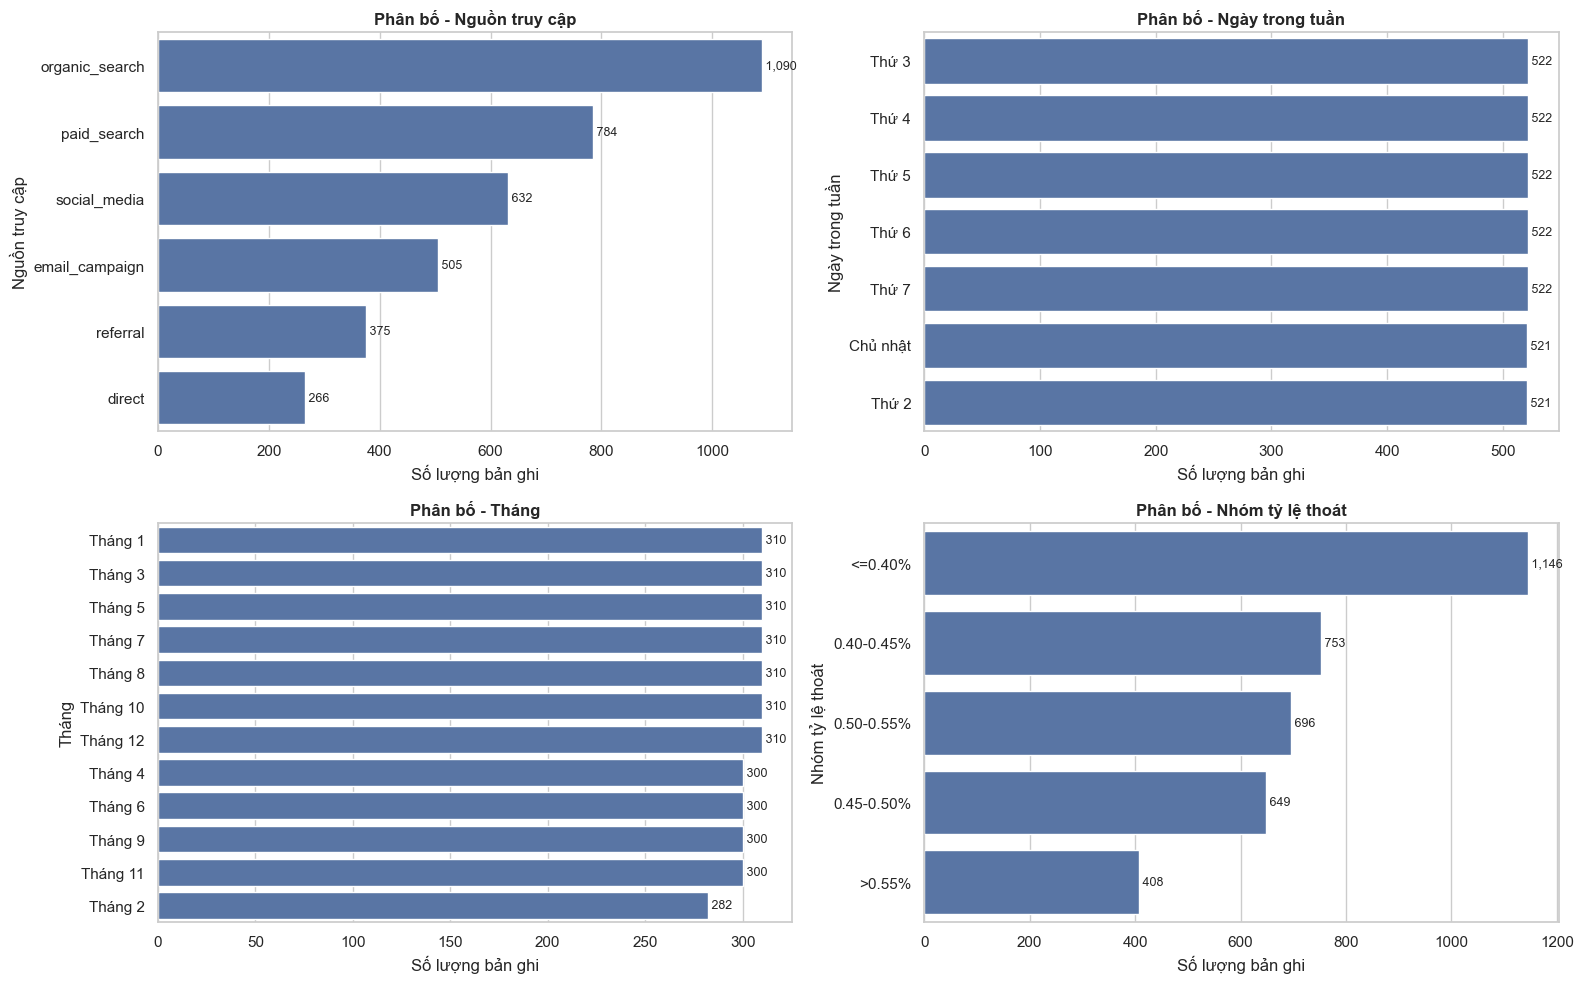

In [61]:
COL_INFO = {
    'traffic_source': {'name': 'Nguồn truy cập', 'unit': 'bản ghi'},
    'day_of_week': {'name': 'Ngày trong tuần', 'unit': 'bản ghi'},
    'month_name': {'name': 'Tháng', 'unit': 'bản ghi'},
    'bounce_band': {'name': 'Nhóm tỷ lệ thoát', 'unit': 'bản ghi'}
}

def plot_horizontal_bar_chart(df, cate_cols_names, save_path=None):
    n = len(cate_cols_names)
    cols = 2
    rows = math.ceil(n / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(16, 5 * rows))
    axes = np.array(axes).reshape(-1)

    for i, col_name in enumerate(cate_cols_names):
        ax = axes[i]

        if col_name in df.columns:
            val_counts = df[col_name].fillna('không xác định').value_counts()

            if len(val_counts) > 12:
                top11 = val_counts.iloc[:11]
                other_sum = val_counts.iloc[11:].sum()
                plot_data = pd.concat([top11, pd.Series({'khác': other_sum})])
            else:
                plot_data = val_counts

            plot_data.index = plot_data.index.astype(str)
            sns.barplot(x=plot_data.values, y=plot_data.index, ax=ax)

            info = COL_INFO.get(col_name, {'name': col_name, 'unit': 'nhóm'})
            ax.set_title(f"Phân bố - {info['name']}", fontweight='bold')
            ax.set_xlabel(f"Số lượng {info['unit']}")
            ax.set_ylabel(info['name'])

            for idx, value in enumerate(plot_data.values):
                ax.text(value, idx, f" {value:,}", va='center', fontsize=9)
        else:
            ax.set_visible(False)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
        print(f'Đã lưu biểu đồ categorical tại: {save_path}')

    plt.show()

plot_horizontal_bar_chart(
    web_traffic_df,
    ['traffic_source', 'day_of_week', 'month_name', 'bounce_band'],
    save_path=os.path.join(IMAGES_DIR, 'web_traffic_categorical_distribution.png')
)

In [62]:
source_stats = web_traffic_df['traffic_source'].value_counts(dropna=False).to_frame(name='count')
source_stats['rate_%'] = (source_stats['count'] / len(web_traffic_df) * 100).round(2)
source_stats

,count,rate_%
traffic_source,,
organic_search,1090,29.85
paid_search,784,21.47
social_media,632,17.31
email_campaign,505,13.83
referral,375,10.27
direct,266,7.28


**Nhận xét:**

- **Quan sát:**
  - `organic_search` là nhóm xuất hiện nhiều nhất trong file với `1,090` bản ghi, chiếm `29.85%`. Sau đó là `paid_search` (`21.47%`), `social_media` (`17.31%`), `email_campaign` (`13.83%`), `referral` (`10.27%`) và thấp nhất là `direct` (`7.28%`).
  - Với grain hiện tại của dữ liệu, các biểu đồ `day_of_week` và `month_name` chủ yếu phản ánh cấu trúc lịch thời gian của tập dữ liệu theo ngày; còn `traffic_source` phản ánh tần suất ngày được gắn với từng nguồn.
  - Nhóm `bounce_band` giúp nhìn nhanh độ phân bố chất lượng traffic theo mức tỷ lệ thoát, tạo nền cho phần cross table phía sau.

- **Insights:**
  - `organic_search` đang là nguồn xuất hiện thường xuyên nhất trong file, cho thấy đây là một thành phần quan trọng của vận hành traffic dài hạn.
  - Tuy nhiên, do mỗi ngày chỉ có một `traffic_source`, số lượng bản ghi theo nguồn không đồng nghĩa trực tiếp với đóng góp traffic volume theo nguồn. Một nguồn ít ngày hơn vẫn có thể tạo ra nhiều sessions hơn trên mỗi ngày.
  - Vì vậy, phần categorical này phù hợp để nhìn cấu trúc nhãn dữ liệu và độ phủ nguồn, nhưng chưa đủ để kết luận hiệu quả business của từng kênh.

- **Gợi ý hành động:**
  - Dùng thêm các bảng tổng hợp theo `avg_sessions`, `avg_page_views` hoặc tổng volume theo nguồn để đánh giá impact thực chất của từng `traffic_source`.
  - Khi đọc biểu đồ `month_name` và `day_of_week`, nên xem đó là tín hiệu hỗ trợ cho phân tích thời gian, không nên diễn giải như market share của traffic.

### 1.1.3. Biến thời gian


In [63]:
monthly_volume = (
    web_traffic_df.groupby('year_month')
    .agg(
        sessions=('sessions', 'sum'),
        unique_visitors=('unique_visitors', 'sum'),
        page_views=('page_views', 'sum')
    )
    .reset_index()
)
monthly_volume['year_month'] = monthly_volume['year_month'].astype(str)
monthly_volume.head()

,year_month,sessions,unique_visitors,page_views
0,2013-01,295006,224927,1249046
1,2013-02,416896,316689,1812512
2,2013-03,622174,477302,2735450
3,2013-04,814380,615275,3495043
4,2013-05,816540,621639,3554250


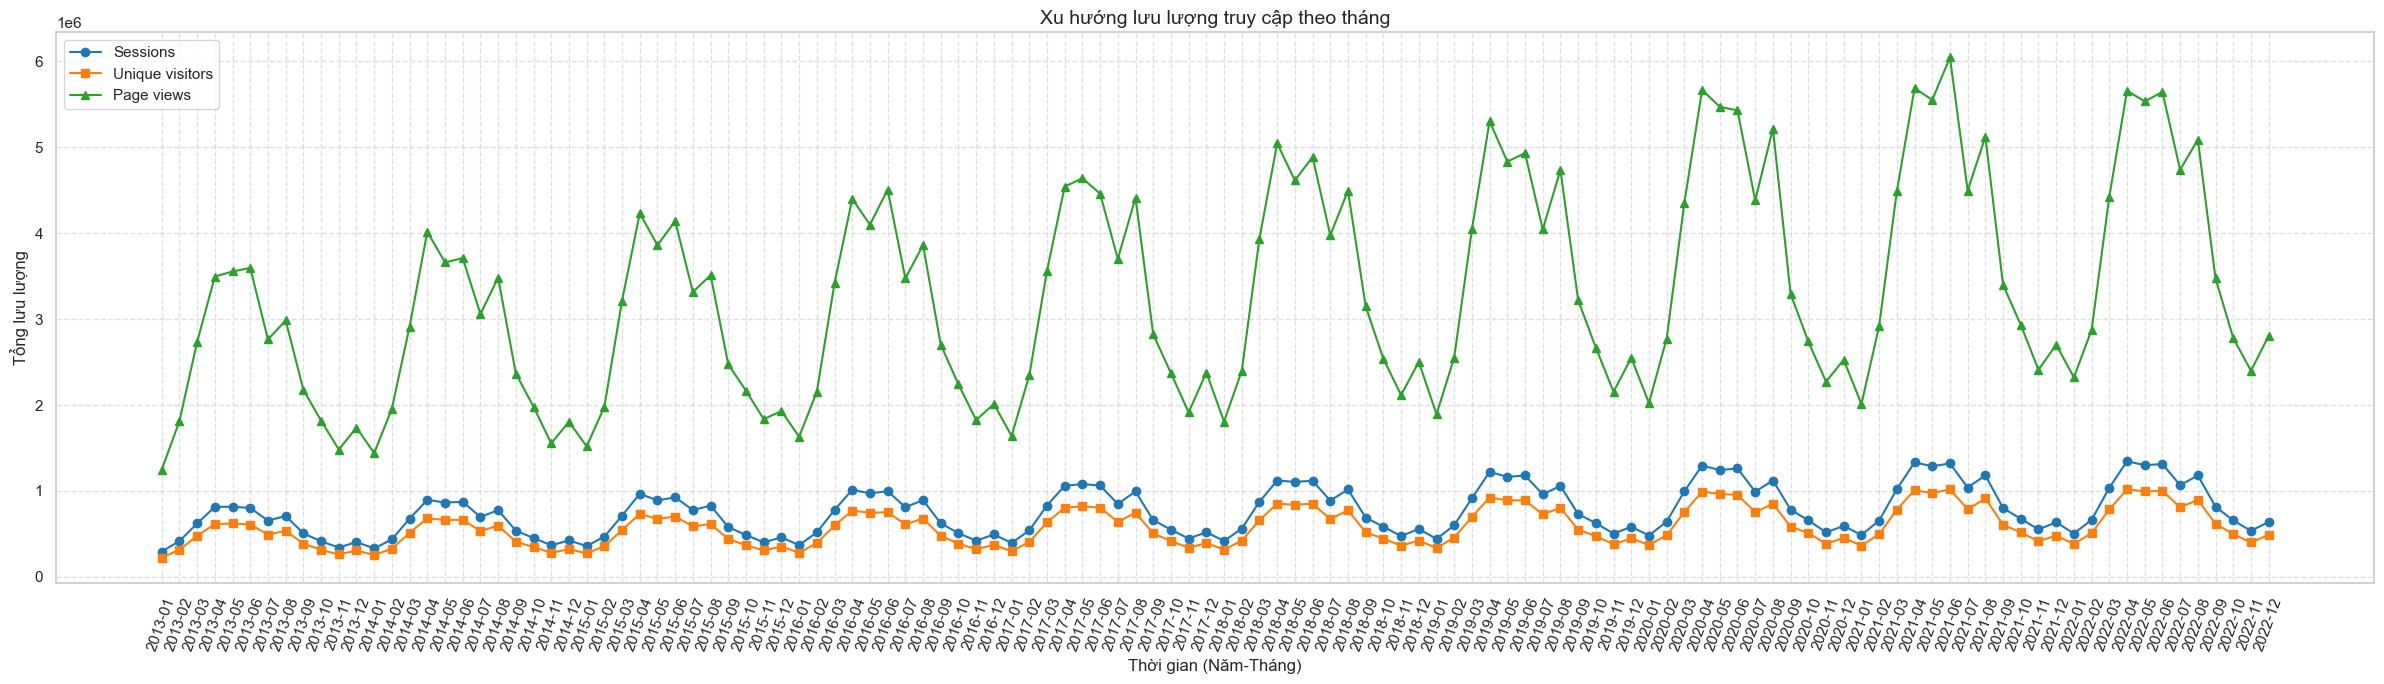

In [64]:
fig, ax = plt.subplots(figsize=(24, 7))
ax.plot(monthly_volume['year_month'], monthly_volume['sessions'], color='tab:blue', marker='o', label='Sessions')
ax.plot(monthly_volume['year_month'], monthly_volume['unique_visitors'], color='tab:orange', marker='s', label='Unique visitors')
ax.plot(monthly_volume['year_month'], monthly_volume['page_views'], color='tab:green', marker='^', label='Page views')
ax.set_title('Xu hướng lưu lượng truy cập theo tháng', fontsize=14)
ax.set_xlabel('Thời gian (Năm-Tháng)')
ax.set_ylabel('Tổng lưu lượng')
ax.tick_params(axis='x', rotation=70)
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend(loc='upper left')
fig.tight_layout()
plt.show()

In [65]:
monthly_quality = (
    web_traffic_df.groupby('year_month')
    .agg(
        avg_bounce_rate_pct=('bounce_rate_pct', 'mean'),
        avg_session_duration_sec=('avg_session_duration_sec', 'mean'),
        avg_engagement_per_session=('engagement_per_session', 'mean')
    )
    .reset_index()
)
monthly_quality['year_month'] = monthly_quality['year_month'].astype(str)
monthly_quality.head()

,year_month,avg_bounce_rate_pct,avg_session_duration_sec,avg_engagement_per_session
0,2013-01,0.45,222.60,4.25
1,2013-02,0.45,205.82,4.35
2,2013-03,0.45,205.85,4.39
3,2013-04,0.47,206.72,4.31
4,2013-05,0.45,208.81,4.35


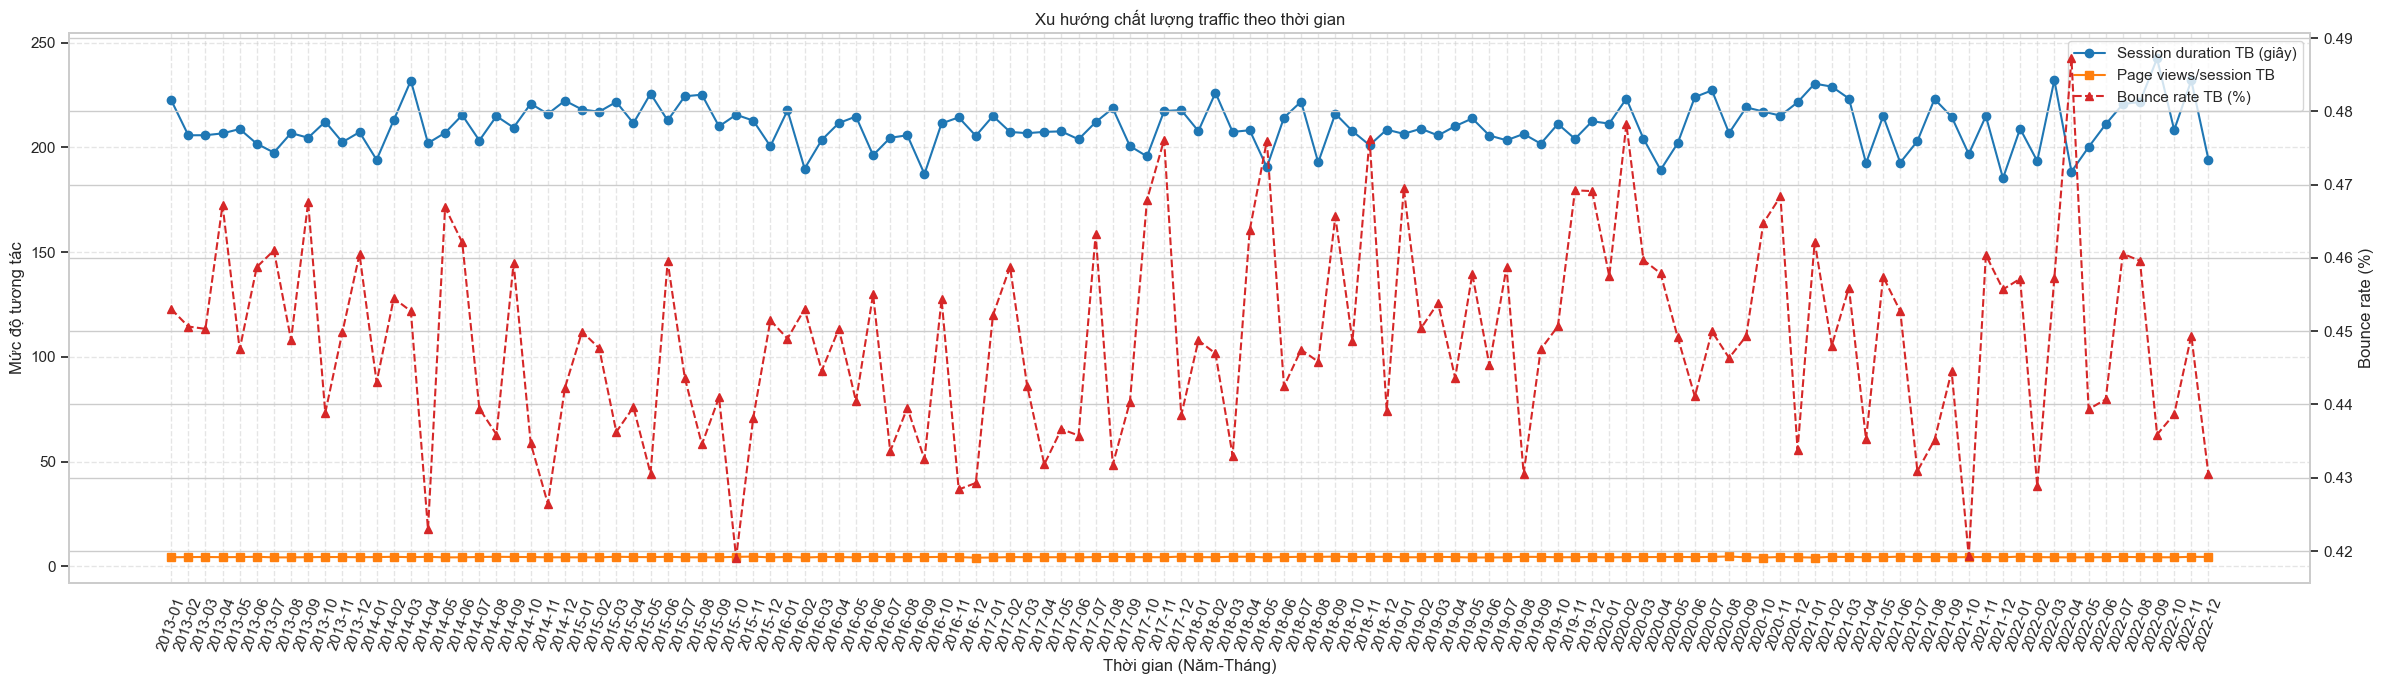

In [66]:
fig, ax1 = plt.subplots(figsize=(24, 7))

ax1.plot(monthly_quality['year_month'], monthly_quality['avg_session_duration_sec'], color='tab:blue', marker='o', label='Session duration TB (giây)')
ax1.plot(monthly_quality['year_month'], monthly_quality['avg_engagement_per_session'], color='tab:orange', marker='s', label='Page views/session TB')
ax1.set_xlabel('Thời gian (Năm-Tháng)')
ax1.set_ylabel('Mức độ tương tác')
ax1.tick_params(axis='x', rotation=70)

ax2 = ax1.twinx()
ax2.plot(monthly_quality['year_month'], monthly_quality['avg_bounce_rate_pct'], color='tab:red', marker='^', linestyle='--', label='Bounce rate TB (%)')
ax2.set_ylabel('Bounce rate (%)')

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper right')
plt.title('Xu hướng chất lượng traffic theo thời gian')
ax1.grid(True, linestyle='--', alpha=0.5)
fig.tight_layout()
plt.show()

**Nhận xét:**

- **Quan sát:**
  - Tổng traffic theo tháng biến động rõ rệt theo chu kỳ. Xét theo mặt bằng trung bình tháng trong năm, `sessions` tăng mạnh từ quý I và đạt vùng cao nhất vào khoảng tháng `04-06`, sau đó giảm dần về cuối năm; riêng tháng `01` là vùng thấp nhất.
  - `page_views` và `unique_visitors` di chuyển cùng chiều rất sát với `sessions`, cho thấy các đợt tăng traffic không chỉ kéo thêm phiên mà còn kéo tăng tổng lượng tiêu thụ nội dung.
  - Nhóm chỉ số chất lượng (`avg_session_duration_sec`, `avg_engagement_per_session`, `avg_bounce_rate_pct`) cũng dao động theo thời gian nhưng biên độ hẹp hơn đáng kể so với volume. Nói cách khác, lượng truy cập biến động mạnh hơn chất lượng truy cập.

- **Insights:**
  - Website có dấu hiệu seasonality tương đối rõ, với giai đoạn cao điểm tập trung quanh quý II và đầu quý III. Đây có thể là thời điểm campaign hiệu quả hơn hoặc nhu cầu thị trường tăng cao.
  - Việc các chỉ số chất lượng không biến động cực mạnh cùng với volume là một tín hiệu tích cực: hệ thống traffic tăng trưởng theo mùa nhưng chưa cho thấy sự suy giảm chất lượng rõ ràng ở mọi giai đoạn cao điểm.

- **Gợi ý hành động:**
  - Dùng các tháng cao điểm làm mốc để lập kế hoạch ngân sách media, chuẩn bị năng lực hạ tầng và nội dung landing page trước mùa tăng trưởng.
  - Soi sâu các tháng có chất lượng lệch nền rõ hơn bình thường để tìm nguyên nhân từ campaign mix, nội dung, thiết bị hoặc thay đổi trải nghiệm website.

## 1.2. Phân tích 2 biến


### 1.2.1. Phân tích tương quan


In [67]:
corr_cols = [
    'sessions', 'unique_visitors', 'page_views', 'bounce_rate_pct',
    'avg_session_duration_sec', 'engagement_per_session', 'visitor_session_ratio'
]
corr_df = web_traffic_df[corr_cols].corr()
corr_df

,sessions,unique_visitors,page_views,bounce_rate_pct,avg_session_duration_sec,engagement_per_session,visitor_session_ratio
sessions,1.00,0.99,0.92,-0.00,-0.02,0.00,0.01
unique_visitors,0.99,1.00,0.91,-0.00,-0.02,0.00,0.13
page_views,0.92,0.91,1.00,0.01,-0.02,0.37,0.00
bounce_rate_pct,-0.00,-0.00,0.01,1.00,0.01,0.04,0.01
avg_session_duration_sec,-0.02,-0.02,-0.02,0.01,1.00,-0.00,-0.01
engagement_per_session,0.00,0.00,0.37,0.04,-0.00,1.00,-0.01
visitor_session_ratio,0.01,0.13,0.00,0.01,-0.01,-0.01,1.00


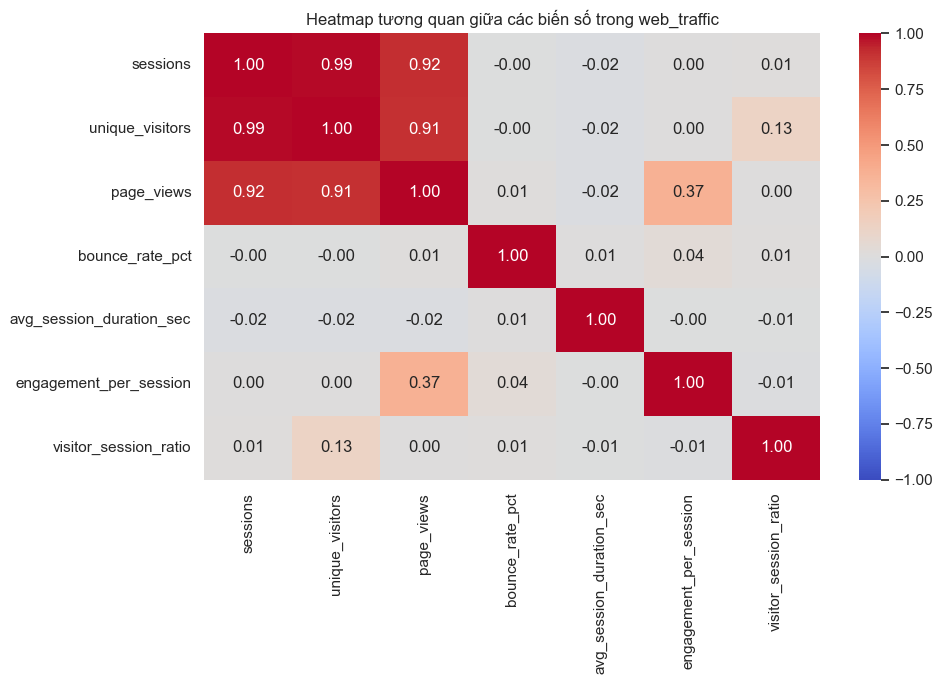

In [68]:
plt.figure(figsize=(10, 7))
sns.heatmap(corr_df, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Heatmap tương quan giữa các biến số trong web_traffic')
plt.tight_layout()
plt.show()

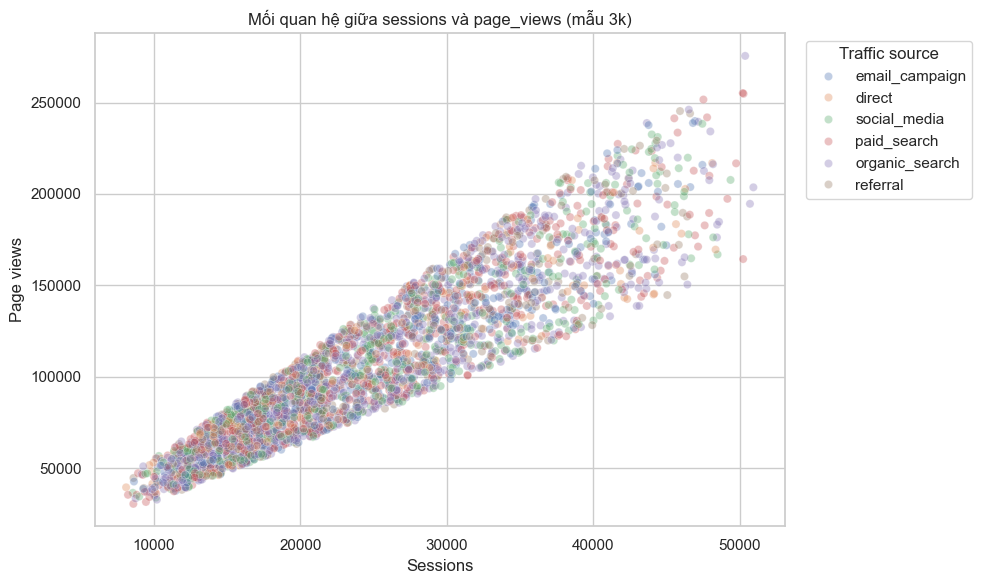

In [69]:
sample_scatter = web_traffic_df.sample(n=min(3000, len(web_traffic_df)), random_state=42)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=sample_scatter,
    x='sessions',
    y='page_views',
    hue='traffic_source',
    alpha=0.35,
    s=35
)
plt.title('Mối quan hệ giữa sessions và page_views (mẫu 3k)')
plt.xlabel('Sessions')
plt.ylabel('Page views')
plt.legend(title='Traffic source', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

### 1.2.2. Phân tích cross table


In [70]:
cross_abs = pd.crosstab(web_traffic_df['traffic_source'], web_traffic_df['bounce_band'])
cross_abs

bounce_band,<=0.40%,0.40-0.45%,0.45-0.50%,0.50-0.55%,>0.55%
traffic_source,,,,,
direct,80,57,45,51,33
email_campaign,161,115,79,104,46
organic_search,339,211,203,207,130
paid_search,253,169,123,143,96
referral,109,80,74,72,40
social_media,204,121,125,119,63


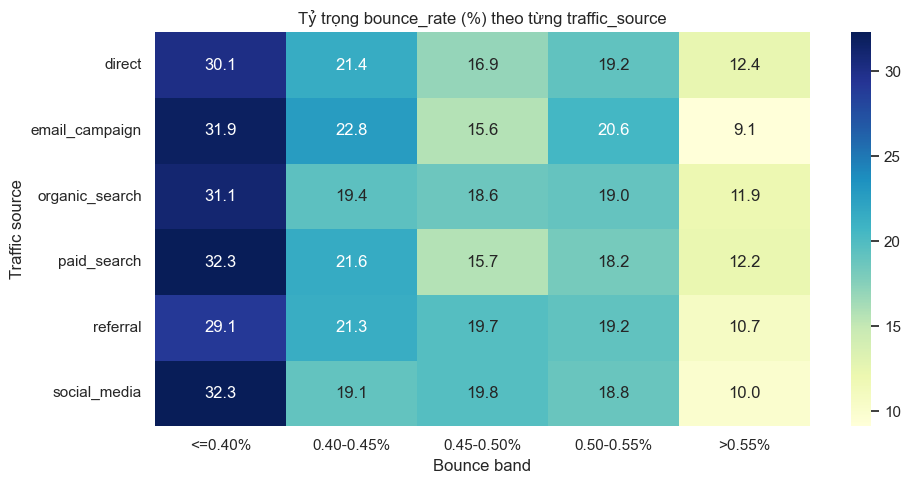

In [71]:
cross_row_pct = pd.crosstab(
    web_traffic_df['traffic_source'],
    web_traffic_df['bounce_band'],
    normalize='index'
) * 100

plt.figure(figsize=(10, 5))
sns.heatmap(cross_row_pct, annot=True, fmt='.1f', cmap='YlGnBu')
plt.title('Tỷ trọng bounce_rate (%) theo từng traffic_source')
plt.xlabel('Bounce band')
plt.ylabel('Traffic source')
plt.tight_layout()
plt.show()

In [72]:
source_quality_stats = (
    web_traffic_df.groupby('traffic_source', as_index=False)
    .agg(
        avg_sessions=('sessions', 'mean'),
        avg_unique_visitors=('unique_visitors', 'mean'),
        avg_page_views=('page_views', 'mean'),
        avg_bounce_rate_pct=('bounce_rate_pct', 'mean'),
        avg_session_duration_sec=('avg_session_duration_sec', 'mean'),
        avg_engagement_per_session=('engagement_per_session', 'mean')
    )
    .sort_values('avg_sessions', ascending=False)
)
source_quality_stats

,traffic_source,avg_sessions,avg_unique_visitors,avg_page_views,avg_bounce_rate_pct,avg_session_duration_sec,avg_engagement_per_session
1,email_campaign,25332.02,19208.84,109856.70,0.45,213.22,4.32
4,referral,25271.59,19253.38,111081.76,0.45,207.56,4.39
5,social_media,25025.67,19063.39,107709.08,0.45,210.29,4.31
3,paid_search,24997.79,19033.66,108519.84,0.45,209.36,4.33
2,organic_search,24951.35,18922.12,107895.83,0.45,211.15,4.32
0,direct,24705.07,18746.80,108163.02,0.45,207.68,4.41


**Nhận xét:**

- **Quan sát:**
  - Ma trận tương quan cho thấy `sessions` và `unique_visitors` có tương quan rất mạnh (`~0.99`), trong khi `sessions` và `page_views` cũng tương quan cao (`~0.92`). Scatter plot vì vậy tạo thành một cụm xu hướng tăng khá rõ và gần tuyến tính.
  - `bounce_rate_pct` gần như không có tương quan tuyến tính mạnh với các biến volume chính. Điều này cho thấy traffic tăng chưa đồng nghĩa trực tiếp với bounce xấu đi hoặc tốt lên theo một chiều cố định.
  - Cross table `traffic_source x bounce_band` cho thấy phân bố bounce band giữa các nguồn khá giống nhau: nhóm `<=0.40%` chiếm khoảng `29-32%` ở hầu hết nguồn, còn nhóm `>0.55%` chỉ quanh `9-12%`.
  - Ở bảng `source_quality_stats`, `email_campaign` có `avg_sessions` cao nhất (`25.3k/ngày`), `referral` có `avg_page_views` cao nhất (`111.1k/ngày`), còn `direct` có `avg_engagement_per_session` cao nhất (`4.41`). Chênh lệch giữa các nguồn có tồn tại nhưng không quá cực đoan.

- **Insights:**
  - Về mặt hành vi tổng quát, volume traffic và mức tiêu thụ nội dung đi cùng nhau rất chặt, nên `sessions` có thể được dùng như một chỉ báo nền khá tốt cho quy mô hoạt động website.
  - Ngược lại, khác biệt về `traffic_source` chưa đủ mạnh để tự giải thích sự chênh lệch bounce rate. Nói cách khác, chất lượng phiên có thể còn bị chi phối bởi các yếu tố khác như landing page, intent người dùng, thiết bị hoặc campaign content.
  - Việc các nguồn có profile chất lượng tương đối gần nhau cho thấy bài toán tối ưu web traffic có lẽ nằm ở chất lượng thực thi trong từng nguồn, hơn là chỉ đổi mix nguồn một cách cơ học.

- **Gợi ý hành động:**
  - Nếu cần tối ưu bounce hoặc engagement, nên drill-down thêm theo `landing_page`, `device`, `campaign` hoặc nhóm nội dung thay vì chỉ dừng ở `traffic_source`.
  - Ưu tiên theo dõi song song hai lớp KPI: lớp volume (`sessions`, `page_views`) và lớp chất lượng (`bounce_rate_pct`, `avg_session_duration_sec`, `engagement_per_session`) để tránh tối ưu tăng traffic nhưng giảm chất lượng.

### **Câu hỏi: Xu hướng thanh toán theo thời gian tác động đến doanh thu và có mối liên hệ như thế nào với biến động của lưu lượng truy cập web?**

#### Câu hỏi nhỏ 1: Sự bùng nổ của các phiên truy cập (sessions) từ các chiến dịch trả phí (paid_search) có kéo theo sự gia tăng của các phương thức thanh toán trả góp (hoặc mua trước trả sau), từ đó đẩy mạnh doanh thu trong các ngày cao điểm không?

#### Câu hỏi nhỏ 2: Tỷ lệ thoát (bounce_rate) cao và thời lượng phiên thấp có làm sụt giảm tỷ lệ hoàn tất thanh toán qua các cổng thanh toán nhanh (như ví điện tử), gây thất thoát doanh thu ngay cả khi traffic tăng vọt?

#### Câu hỏi nhỏ 3: Khách truy cập có độ tương tác sâu (page_views/session cao) thường ưu tiên chọn phương thức thanh toán nào theo thời gian, và sự chuyển dịch phương thức này tác động ra sao vào việc chốt sale để tạo doanh thu?